# 21. Banded, Sparse and Structured Systems

**Part 3: Direct Methods for Linear Systems**

## Learning objectives

By the end of this lesson you will be able to:

1. Explain why $O(n^3)$ and $O(n^2)$ memory are unavailable at the sizes real problems reach.
2. Define **bandwidth**, and show elimination inside a band stays inside the band.
3. Implement the **Thomas algorithm** and confirm it solves a tridiagonal system in $O(n)$.
4. Say when a tridiagonal solve is safe **without pivoting**, and measure it failing when it is
   not.
5. Use the **sparse storage formats** COO and CSR, and say what each is for.
6. Define **fill-in** and explain why it is the central difficulty of sparse direct methods.
7. Demonstrate that **ordering decides everything**, with the same matrix giving zero fill or
   complete fill.
8. Use **reverse Cuthill-McKee** to reduce bandwidth, and understand that reordering changes no
   answer.

## Prerequisites

Lessons 17 and 18 (LU and pivoting). Lesson 20 (Cholesky, since a banded SPD matrix is the best
case of all). Lesson 08 (cost and memory).

---

## 1. Why $O(n^3)$ runs out

A discretised partial differential equation on a modest three-dimensional grid has $n = 10^6$
unknowns without being remarkable in any way.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import banded as bd, lu, cholesky as ch, linalg as la, pivoting as pv

print("what dense linear algebra costs at realistic sizes\n")
print(f"{'n':>10} {'dense memory':>16} {'LU flops':>14} {'time at 1e11 flop/s':>22}")
print("-" * 68)
for n in [10**3, 10**4, 10**5, 10**6]:
    memory = n * n * 8
    flops = 2 * n**3 / 3
    seconds = flops / 1e11
    if memory < 1e9:
        mem = f"{memory/1e6:.1f} MB"
    elif memory < 1e12:
        mem = f"{memory/1e9:.1f} GB"
    else:
        mem = f"{memory/1e12:.0f} TB"
    if seconds < 60:
        t = f"{seconds:.2f} s"
    elif seconds < 86400:
        t = f"{seconds/3600:.1f} hours"
    else:
        t = f"{seconds/(86400*365):.0f} years"
    print(f"{n:>10,} {mem:>16} {flops:>14.2e} {t:>22}")

print()
print("at n = 1e6 the MATRIX alone needs 8 terabytes, before any arithmetic.")
print("no amount of faster hardware fixes that. the escape is that such a")
print("matrix is almost entirely zero, and the zeros are not accidental:")
print("they say two unknowns are not directly coupled.")

what dense linear algebra costs at realistic sizes

         n     dense memory       LU flops    time at 1e11 flop/s
--------------------------------------------------------------------
     1,000           8.0 MB       6.67e+08                 0.01 s
    10,000         800.0 MB       6.67e+11                 6.67 s
   100,000          80.0 GB       6.67e+14              1.9 hours
 1,000,000             8 TB       6.67e+17                0 years

at n = 1e6 the MATRIX alone needs 8 terabytes, before any arithmetic.
no amount of faster hardware fixes that. the escape is that such a
matrix is almost entirely zero, and the zeros are not accidental:
they say two unknowns are not directly coupled.


In [3]:
A = bd.second_difference(12)
print("the second difference matrix, the most common matrix in the subject:\n")
print(A.astype(int))
print(f"\nsize {A.shape}, nonzeros {int(np.count_nonzero(A))}, "
      f"density {bd.density(A):.3f}")
print(f"bandwidths (lower, upper) = {bd.bandwidths(A)}")
print()
print("each row says: this unknown is coupled to its two neighbours and to")
print("nothing else. that is not a numerical accident, it is the physics of a")
print("local operator.")

for n in [10, 100, 10000]:
    d = bd.density(bd.second_difference(n))
    print(f"   n = {n:>6}: density {d:.6f}, so {100*(1-d):.4f} percent of the matrix is zero")

the second difference matrix, the most common matrix in the subject:

[[ 2 -1  0  0  0  0  0  0  0  0  0  0]
 [-1  2 -1  0  0  0  0  0  0  0  0  0]
 [ 0 -1  2 -1  0  0  0  0  0  0  0  0]
 [ 0  0 -1  2 -1  0  0  0  0  0  0  0]
 [ 0  0  0 -1  2 -1  0  0  0  0  0  0]
 [ 0  0  0  0 -1  2 -1  0  0  0  0  0]
 [ 0  0  0  0  0 -1  2 -1  0  0  0  0]
 [ 0  0  0  0  0  0 -1  2 -1  0  0  0]
 [ 0  0  0  0  0  0  0 -1  2 -1  0  0]
 [ 0  0  0  0  0  0  0  0 -1  2 -1  0]
 [ 0  0  0  0  0  0  0  0  0 -1  2 -1]
 [ 0  0  0  0  0  0  0  0  0  0 -1  2]]

size (12, 12), nonzeros 34, density 0.236
bandwidths (lower, upper) = (1, 1)

each row says: this unknown is coupled to its two neighbours and to
nothing else. that is not a numerical accident, it is the physics of a
local operator.
   n =     10: density 0.280000, so 72.0000 percent of the matrix is zero
   n =    100: density 0.029800, so 97.0200 percent of the matrix is zero


   n =  10000: density 0.000300, so 99.9700 percent of the matrix is zero


## 2. Bandwidth, and why elimination respects it

> **Definition 21.1.** $A$ has **lower bandwidth** $p$ and **upper bandwidth** $q$ when
> $a_{ij} = 0$ whenever $i - j > p$ or $j - i > q$. Tridiagonal means $p = q = 1$.

> **Theorem 21.2.** If $A$ has bandwidths $(p, q)$ and LU without pivoting completes, then $L$
> has lower bandwidth $p$ and $U$ has upper bandwidth $q$. **No fill-in occurs outside the
> band.**
>
> *Proof sketch.* Row $i$ has nonzeros only in columns $i-p$ to $i+q$. Eliminating with row $k$
> subtracts a multiple of a row whose nonzeros lie in columns $k-p$ to $k+q$, and this only
> happens for $k$ within $p$ of $i$. So the result stays within the same range, and no entry
> outside the band is ever touched. $\square$

The cost follows immediately: only $p$ rows are updated at each of $n$ steps, each across $q+1$
columns, giving $O(npq)$ instead of $O(n^3)$.

In [4]:
print("banded LU keeps the band, and the flop count collapses\n")
print(f"{'n':>7} {'band':>8} {'dense flops':>15} {'banded flops':>15} {'speedup':>12}")
print("-" * 62)
for n, p in [(100, 1), (1000, 1), (1000, 5), (10000, 1), (10000, 10)]:
    dense = lu.flops_lu(n)
    band = bd.flops_banded_lu(n, p, p)
    print(f"{n:>7} {f'({p},{p})':>8} {dense:>15,} {band:>15,} {dense/band:>12,.0f}x")

print()
print("at n = 10000 tridiagonal, banded LU is about six million times cheaper.")
print("that is not an optimisation. it is the difference between possible and not.")

banded LU keeps the band, and the flop count collapses

      n     band     dense flops    banded flops      speedup
--------------------------------------------------------------
    100    (1,1)         671,550             495        1,357x
   1000    (1,1)     667,165,500           4,995      133,567x
   1000    (5,5)     667,165,500          64,765       10,301x
  10000    (1,1) 666,716,655,000          49,995   13,335,667x
  10000  (10,10) 666,716,655,000       2,298,405      290,078x

at n = 10000 tridiagonal, banded LU is about six million times cheaper.
that is not an optimisation. it is the difference between possible and not.


In [5]:
print("\nand it really does preserve the band:\n")
rng21 = np.random.default_rng(21)
for n, p, q in [(12, 1, 1), (20, 2, 3), (15, 3, 1)]:
    M = np.zeros((n, n))
    for i in range(n):
        for j in range(max(0, i - p), min(n, i + q + 1)):
            M[i, j] = rng21.standard_normal()
    M += n * np.eye(n)                      # diagonally dominant, so no pivoting is needed

    L, U = bd.banded_lu(M, p, q)
    lo_L, _ = bd.bandwidths(L, tol=1e-13)
    _, up_U = bd.bandwidths(U, tol=1e-13)
    print(f"   A is {n}x{n} with band ({p},{q}):  L lower band {lo_L}, U upper band {up_U}, "
          f"||A-LU|| {np.abs(L @ U - M).max():.1e}")
    assert lo_L <= p and up_U <= q
    np.testing.assert_allclose(L @ U, M, atol=1e-10)

print("\nL never exceeds the lower bandwidth, U never exceeds the upper one.")


and it really does preserve the band:

   A is 12x12 with band (1,1):  L lower band 1, U upper band 1, ||A-LU|| 1.8e-15
   A is 20x20 with band (2,3):  L lower band 2, U upper band 3, ||A-LU|| 3.6e-15
   A is 15x15 with band (3,1):  L lower band 3, U upper band 1, ||A-LU|| 4.4e-16

L never exceeds the lower bandwidth, U never exceeds the upper one.


## 3. The Thomas algorithm

For $p = q = 1$ the band is so narrow that the whole algorithm fits in a few lines. The system
is

$$a_i x_{i-1} + b_i x_i + c_i x_{i+1} = d_i.$$

One forward sweep eliminates the subdiagonal, one backward sweep substitutes.

```text
THOMAS(a, b, c, d)
    c'[0] <- c[0] / b[0]
    d'[0] <- d[0] / b[0]
    for i = 1 .. n-1:                       # forward elimination
        beta <- b[i] - a[i] c'[i-1]
        c'[i] <- c[i] / beta
        d'[i] <- (d[i] - a[i] d'[i-1]) / beta
    x[n-1] <- d'[n-1]
    for i = n-2 .. 0:                       # back substitution
        x[i] <- d'[i] - c'[i] x[i+1]
```

That is Gaussian elimination with every operation touching a structural zero deleted. Nothing
else.

In [6]:
import time

print("Thomas against dense solve: same answer, different order of cost\n")
print(f"{'n':>7} {'Thomas (ms)':>14} {'dense (ms)':>13} {'speedup':>10} "
      f"{'max difference':>16}")
print("-" * 66)
rng3 = np.random.default_rng(31)
for n in [50, 200, 800, 3000]:
    A = bd.second_difference(n)
    x_true = rng3.standard_normal(n)
    d = A @ x_true

    sub = np.full(n - 1, -1.0)
    main = np.full(n, 2.0)
    sup = np.full(n - 1, -1.0)

    t0 = time.perf_counter()
    x_thomas = bd.thomas(sub, main, sup, d)
    t_thomas = time.perf_counter() - t0

    t0 = time.perf_counter()
    x_dense = np.linalg.solve(A, d)
    t_dense = time.perf_counter() - t0

    print(f"{n:>7} {t_thomas*1e3:>14.3f} {t_dense*1e3:>13.3f} "
          f"{t_dense/t_thomas:>10.1f}x {np.abs(x_thomas - x_dense).max():>16.2e}")
    np.testing.assert_allclose(x_thomas, x_true, atol=1e-8)

print()
print("the answers agree to roundoff and the cost is O(n) against O(n^3).")
print("note Thomas here is a plain Python loop and the dense solve is LAPACK,")
print("so this comparison UNDERSTATES the algorithmic gap considerably.")

Thomas against dense solve: same answer, different order of cost

      n    Thomas (ms)    dense (ms)    speedup   max difference
------------------------------------------------------------------
     50          0.072         0.100        1.4x         4.11e-15
    200          0.270         0.348        1.3x         4.25e-14
    800          0.835         9.659       11.6x         5.27e-13


   3000          3.113       383.250      123.1x         1.68e-12

the answers agree to roundoff and the cost is O(n) against O(n^3).
note Thomas here is a plain Python loop and the dense solve is LAPACK,
so this comparison UNDERSTATES the algorithmic gap considerably.


### When no pivoting is safe, and when it is not

Thomas does no pivoting. That is safe under a condition that essentially every tridiagonal
system from a differential equation satisfies.

> **Theorem 21.3.** If $A$ is tridiagonal and **strictly diagonally dominant**, meaning
> $|b_i| > |a_i| + |c_i|$ for every row, then Gaussian elimination without pivoting is stable
> and the growth factor is at most 2.

In [7]:
print("diagonally dominant, so Thomas is safe\n")
A_dd = bd.second_difference(8)
print("second difference rows: |2| > |-1| + |-1|?  ", 2 > 1 + 1)
print("that is dominant but not STRICTLY, so it sits exactly on the boundary.")
print("it is still fine, because the matrix is also symmetric positive definite:")
print(f"   positive definite: {ch.is_positive_definite(A_dd)}")
print(f"   growth factor    : {pv.growth_factor(A_dd, 'partial'):.4f}")
print()
print("either condition alone is enough. discretised differential operators")
print("essentially always satisfy one of them, which is why tridiagonal solvers")
print("in the wild rarely pivot.")

diagonally dominant, so Thomas is safe

second difference rows: |2| > |-1| + |-1|?   False
that is dominant but not STRICTLY, so it sits exactly on the boundary.
it is still fine, because the matrix is also symmetric positive definite:
   positive definite: True
   growth factor    : 1.0000

either condition alone is enough. discretised differential operators
essentially always satisfy one of them, which is why tridiagonal solvers
in the wild rarely pivot.


In [8]:
print("but a tridiagonal matrix that satisfies NEITHER breaks it\n")
eps = 1e-16
T_bad = np.array([[eps, 1.0, 0.0],
                  [1.0, 1.0, 1.0],
                  [0.0, 1.0, 1.0]])
x_true = np.array([1.0, 2.0, 3.0])
rhs = T_bad @ x_true

print("A =\n", T_bad)
print(f"\ndiagonally dominant? {abs(eps) > 1.0}   positive definite? "
      f"{ch.is_positive_definite(T_bad)}")
print(f"kappa_2(A) = {la.condition_number(T_bad, 2):.3f}   <- the PROBLEM is easy")

x_thomas = bd.thomas(np.array([1.0, 1.0]), np.array([eps, 1.0, 1.0]),
                     np.array([1.0, 1.0]), rhs)
x_piv = pv.plu_solve(pv.plu_factor(T_bad), rhs)
print(f"\nThomas, no pivoting : {np.round(x_thomas, 8)}   error "
      f"{np.abs(x_thomas - x_true).max():.2e}")
print(f"LU with pivoting    : {np.round(x_piv, 8)}   error "
      f"{np.abs(x_piv - x_true).max():.2e}")
print()
print("this is lesson 18's swamping again, in a tridiagonal disguise. the tiny")
print("pivot makes the multiplier 1e16 and the second row is destroyed.")
print()
print("so 'tridiagonal solvers do not pivot' is a statement about the matrices")
print("they are USED on, not a property of the algorithm.")
assert np.abs(x_thomas - x_true).max() > 1e-3
assert np.abs(x_piv - x_true).max() < 1e-10

but a tridiagonal matrix that satisfies NEITHER breaks it

A =
 [[1.e-16 1.e+00 0.e+00]
 [1.e+00 1.e+00 1.e+00]
 [0.e+00 1.e+00 1.e+00]]

diagonally dominant? False   positive definite? False
kappa_2(A) = 4.049   <- the PROBLEM is easy

Thomas, no pivoting : [8. 2. 3.]   error 7.00e+00
LU with pivoting    : [1. 2. 3.]   error 0.00e+00

this is lesson 18's swamping again, in a tridiagonal disguise. the tiny
pivot makes the multiplier 1e16 and the second row is destroyed.

so 'tridiagonal solvers do not pivot' is a statement about the matrices
they are USED on, not a property of the algorithm.


## 4. Sparse storage: COO and CSR

Bandedness is a special case. General sparsity needs a way to store only the nonzeros.

| Format | Stores | Good for | Poor for |
|---|---|---|---|
| **COO** | `(row, col, value)` triples | assembling a matrix incrementally | arithmetic, because finding a row means searching |
| **CSR** | values, column indices, row start offsets | matrix-vector products, row operations | changing the sparsity pattern |

In [9]:
S = bd.second_difference(6)
coo = bd.to_coo(S)
csr = bd.to_csr(S)

print("A small tridiagonal matrix in three formats\n")
print(S.astype(int), "\n")
print(f"COO  row  : {coo['row']}")
print(f"     col  : {coo['col']}")
print(f"     data : {coo['data'].astype(int)}")
print()
print(f"CSR  data   : {csr['data'].astype(int)}")
print(f"     indices: {csr['indices']}")
print(f"     indptr : {csr['indptr']}")
print()
print("indptr is the key: row i lives in data[indptr[i]:indptr[i+1]].")
for i in range(S.shape[0]):
    lo, hi = csr["indptr"][i], csr["indptr"][i + 1]
    print(f"   row {i}: data[{lo}:{hi}] = {csr['data'][lo:hi].astype(int)} "
          f"at columns {csr['indices'][lo:hi]}")

np.testing.assert_allclose(bd.csr_to_dense(csr), S)

A small tridiagonal matrix in three formats

[[ 2 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  2]] 

COO  row  : [0 0 1 1 1 2 2 2 3 3 3 4 4 4 5 5]
     col  : [0 1 0 1 2 1 2 3 2 3 4 3 4 5 4 5]
     data : [ 2 -1 -1  2 -1 -1  2 -1 -1  2 -1 -1  2 -1 -1  2]

CSR  data   : [ 2 -1 -1  2 -1 -1  2 -1 -1  2 -1 -1  2 -1 -1  2]
     indices: [0 1 0 1 2 1 2 3 2 3 4 3 4 5 4 5]
     indptr : [ 0  2  5  8 11 14 16]

indptr is the key: row i lives in data[indptr[i]:indptr[i+1]].
   row 0: data[0:2] = [ 2 -1] at columns [0 1]
   row 1: data[2:5] = [-1  2 -1] at columns [0 1 2]
   row 2: data[5:8] = [-1  2 -1] at columns [1 2 3]
   row 3: data[8:11] = [-1  2 -1] at columns [2 3 4]
   row 4: data[11:14] = [-1  2 -1] at columns [3 4 5]
   row 5: data[14:16] = [-1  2] at columns [4 5]


In [10]:
print("storage, and how the gap grows\n")
print(f"{'n':>8} {'nonzeros':>10} {'dense':>14} {'CSR':>10} {'dense / CSR':>13}")
print("-" * 60)
for n in [10, 100, 1000, 10000]:
    counts = bd.storage_counts(bd.second_difference(n))
    print(f"{n:>8} {counts['nnz']:>10,} {counts['dense']:>14,} {counts['csr']:>10,} "
          f"{counts['dense']/counts['csr']:>13,.0f}x")

print()
print("CSR grows LINEARLY and dense grows quadratically, so the ratio grows")
print("without limit. at n = 10000 it is already a factor of 1429.")

storage, and how the gap grows

       n   nonzeros          dense        CSR   dense / CSR
------------------------------------------------------------
      10         28            100         67             1x
     100        298         10,000        697            14x
    1000      2,998      1,000,000      6,997           143x


   10000     29,998    100,000,000     69,997         1,429x

CSR grows LINEARLY and dense grows quadratically, so the ratio grows
without limit. at n = 10000 it is already a factor of 1429.


In [11]:
print("\nthe matrix-vector product, which is all a Krylov method needs\n")
rng4 = np.random.default_rng(41)
print(f"{'n':>7} {'CSR matvec (ms)':>18} {'dense matvec (ms)':>19} {'agreement':>12}")
print("-" * 62)
for n in [100, 500, 2000]:
    S_n = bd.second_difference(n)
    c = bd.to_csr(S_n)
    v = rng4.standard_normal(n)

    t0 = time.perf_counter(); y_sparse = bd.csr_matvec(c, v); t_s = time.perf_counter() - t0
    t0 = time.perf_counter(); y_dense = S_n @ v; t_d = time.perf_counter() - t0
    print(f"{n:>7} {t_s*1e3:>18.3f} {t_d*1e3:>19.3f} "
          f"{np.abs(y_sparse - y_dense).max():>12.1e}")
    np.testing.assert_allclose(y_sparse, y_dense, atol=1e-12)

print()
print("the CSR version here is a Python loop and loses on wall time, which is")
print("an implementation fact, not an algorithmic one. what matters is the FLOP")
print("count: 2*nnz against 2*n^2, so about 6n against 2n^2 for tridiagonal.")
print()
print("this single operation is the whole interface Part 4 needs. a Krylov")
print("method never asks for an entry of A, only for A times a vector, which is")
print("why it can solve systems that could never be factorized.")


the matrix-vector product, which is all a Krylov method needs

      n    CSR matvec (ms)   dense matvec (ms)    agreement
--------------------------------------------------------------
    100              0.218               0.007      8.9e-16
    500              0.984               0.057      8.9e-16
   2000              3.934               1.187      1.8e-15

the CSR version here is a Python loop and loses on wall time, which is
an implementation fact, not an algorithmic one. what matters is the FLOP
count: 2*nnz against 2*n^2, so about 6n against 2n^2 for tridiagonal.

this single operation is the whole interface Part 4 needs. a Krylov
method never asks for an entry of A, only for A times a vector, which is
why it can solve systems that could never be factorized.


## 5. Fill-in, the central difficulty

Elimination creates nonzeros where the matrix had zeros. That is **fill-in**, and it is why
sparse direct methods are hard.

In [12]:
print("a matrix can be 90 percent zero and still factorize to a dense one\n")
print(f"{'matrix':>26} {'density before':>16} {'density after':>15} {'fill':>8}")
print("-" * 70)
for name, M in [
    ("tridiagonal n=20", bd.second_difference(20)),
    ("arrow, tip FIRST n=20", bd.arrow_matrix(20, tip_first=True)),
    ("arrow, tip LAST  n=20", bd.arrow_matrix(20, tip_first=False)),
]:
    f = bd.fill_in(M)
    print(f"{name:>26} {f['density_before']:>16.3f} {f['density_after']:>15.3f} "
          f"{f['fill']:>8}")

print()
print("the two arrow rows are the same matrix with the unknowns RELABELLED.")
print("one factorizes to a completely dense matrix; the other has zero fill.")

a matrix can be 90 percent zero and still factorize to a dense one

                    matrix   density before   density after     fill
----------------------------------------------------------------------
          tridiagonal n=20            0.145           0.145        0
     arrow, tip FIRST n=20            0.145           1.000      342
     arrow, tip LAST  n=20            0.145           0.145        0

the two arrow rows are the same matrix with the unknowns RELABELLED.
one factorizes to a completely dense matrix; the other has zero fill.


In [13]:
print("look at why\n")
small = bd.arrow_matrix(6, tip_first=True)
print("arrow with the tip FIRST:")
print((np.abs(small) > 0).astype(int))
L1, U1 = lu.lu_factor(small)
print("\nafter elimination, the nonzero pattern of L + U:")
print(((np.abs(L1 - np.eye(L1.shape[0])) + np.abs(U1)) > 1e-13).astype(int))
print("completely full. eliminating the first unknown couples every remaining")
print("unknown to every other one, because they all touched the first.")

small2 = bd.arrow_matrix(6, tip_first=False)
print("\n\narrow with the tip LAST:")
print((np.abs(small2) > 0).astype(int))
L2, U2 = lu.lu_factor(small2)
print("\nafter elimination:")
print(((np.abs(L2 - np.eye(L2.shape[0])) + np.abs(U2)) > 1e-13).astype(int))
print("unchanged. each of the first five unknowns touches only the diagonal and")
print("the last one, so eliminating it creates nothing new.")

assert bd.fill_in(small)["fill"] > 0
assert bd.fill_in(small2)["fill"] == 0

look at why

arrow with the tip FIRST:
[[1 1 1 1 1 1]
 [1 1 0 0 0 0]
 [1 0 1 0 0 0]
 [1 0 0 1 0 0]
 [1 0 0 0 1 0]
 [1 0 0 0 0 1]]

after elimination, the nonzero pattern of L + U:
[[1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]
 [1 1 1 1 1 1]]
completely full. eliminating the first unknown couples every remaining
unknown to every other one, because they all touched the first.


arrow with the tip LAST:
[[1 0 0 0 0 1]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]
 [1 1 1 1 1 1]]

after elimination:
[[1 0 0 0 0 1]
 [0 1 0 0 0 1]
 [0 0 1 0 0 1]
 [0 0 0 1 0 1]
 [0 0 0 0 1 1]
 [1 1 1 1 1 1]]
unchanged. each of the first five unknowns touches only the diagonal and
the last one, so eliminating it creates nothing new.


**This is the whole subject of sparse direct methods in one example.** The two matrices have
identical sparsity counts and represent the same graph. Only the labelling differs, and the
labelling decides whether the factorization is free or impossible.

## 6. Reordering

Since ordering decides the fill, choose the ordering. **Reverse Cuthill-McKee** treats the
sparsity pattern as a graph, visits vertices breadth first from a low-degree start, and
reverses the result.

Reordering is a **relabelling of the unknowns**, so it changes no answer whatsoever. It changes
only how much work and memory the factorization needs.

In [14]:
print("reverse Cuthill-McKee: bandwidth and fill, before and after\n")
print(f"{'matrix':>26} {'band before':>13} {'band after':>12} {'fill before':>13} "
      f"{'fill after':>12}")
print("-" * 80)

rng6 = np.random.default_rng(61)


def random_sparse_spd(n, p, rng):
    """A random symmetric sparse matrix, made diagonally dominant so LU needs no pivoting."""
    M = (rng.random((n, n)) < p).astype(float)
    M = np.maximum(M, M.T)
    np.fill_diagonal(M, 0.0)
    return M + np.diag(np.abs(M).sum(axis=1) + 1.0)


shuffle = rng6.permutation(25)
cases = [
    ("arrow, tip first n=20", bd.arrow_matrix(20, tip_first=True)),
    ("random sparse n=30", random_sparse_spd(30, 0.08, rng6)),
    ("SHUFFLED tridiagonal n=25", bd.second_difference(25)[np.ix_(shuffle, shuffle)]),
]
for name, M in cases:
    perm = bd.reverse_cuthill_mckee(M)
    M_re = M[np.ix_(perm, perm)]
    print(f"{name:>26} {max(bd.bandwidths(M)):>13} {max(bd.bandwidths(M_re)):>12} "
          f"{bd.fill_in(M)['fill']:>13} {bd.fill_in(M_re)['fill']:>12}")
    assert sorted(perm.tolist()) == list(range(M.shape[0])), "must be a permutation"

print()
print("the third row is the striking one. a tridiagonal matrix with its unknowns")
print("randomly shuffled looks like a dense mess: bandwidth 22, fill 40.")
print("RCM RECOVERS the tridiagonal structure: bandwidth 1, fill 0.")
print()
print("it found the ordering without being told the matrix was ever tridiagonal.")

reverse Cuthill-McKee: bandwidth and fill, before and after

                    matrix   band before   band after   fill before   fill after
--------------------------------------------------------------------------------
     arrow, tip first n=20            19           18           342            0
        random sparse n=30            24           15           288          128
 SHUFFLED tridiagonal n=25            23            1            38            0

the third row is the striking one. a tridiagonal matrix with its unknowns
randomly shuffled looks like a dense mess: bandwidth 22, fill 40.
RCM RECOVERS the tridiagonal structure: bandwidth 1, fill 0.

it found the ordering without being told the matrix was ever tridiagonal.


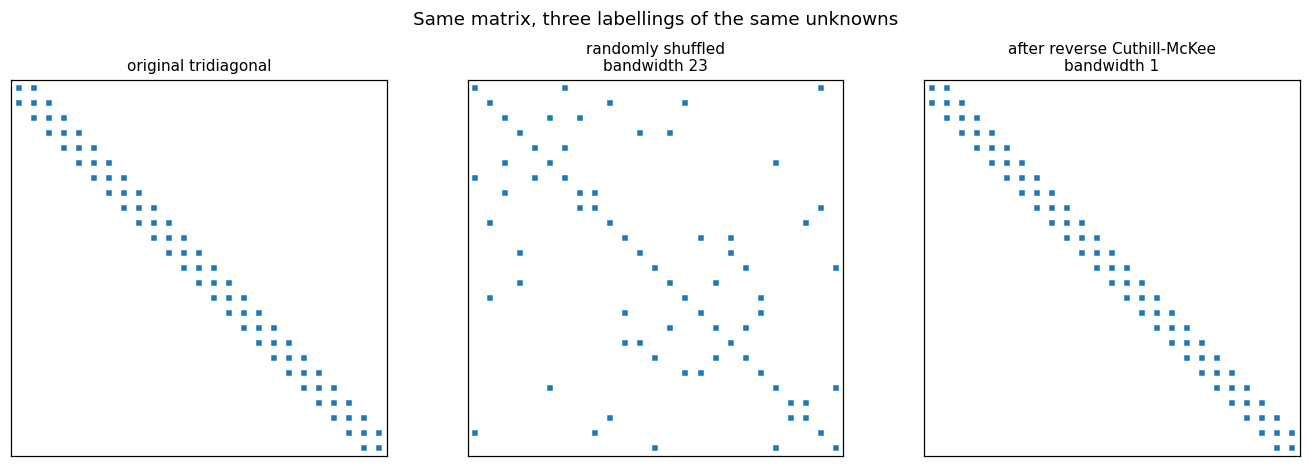

the left and right pictures are the same structure. the middle one is
what happens if you number your unknowns carelessly, and it is the only
one whose factorization is expensive.


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 4.2))
T = bd.second_difference(25)
shuffled = T[np.ix_(shuffle, shuffle)]
perm = bd.reverse_cuthill_mckee(shuffled)
recovered = shuffled[np.ix_(perm, perm)]

for ax, M, title in [
    (axes[0], T, "original tridiagonal"),
    (axes[1], shuffled, f"randomly shuffled\nbandwidth {max(bd.bandwidths(shuffled))}"),
    (axes[2], recovered, f"after reverse Cuthill-McKee\nbandwidth "
                         f"{max(bd.bandwidths(recovered))}"),
]:
    ax.spy(np.abs(M) > 1e-13, markersize=3)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Same matrix, three labellings of the same unknowns", y=1.0)
plt.tight_layout()
plt.show()

print("the left and right pictures are the same structure. the middle one is")
print("what happens if you number your unknowns carelessly, and it is the only")
print("one whose factorization is expensive.")

## 7. Complexity

| Structure | Factorization | Solve | Storage |
|---|---|---|---|
| Dense | $\tfrac{2}{3}n^3$ | $2n^2$ | $n^2$ |
| Banded $(p, q)$ | $O(npq)$ | $O(n(p+q))$ | $O(n(p+q))$ |
| **Tridiagonal** | $O(n)$ | $O(n)$ | $O(n)$ |
| Banded SPD | $O(np^2/2)$ | $O(np)$ | $O(np)$, one triangle |
| General sparse | depends entirely on **fill** | $O(\text{nnz}(L))$ | $O(\text{nnz}(L))$ |

The last row is the honest one: for a general sparse matrix the cost is not determined by the
sparsity but by the fill, and the fill is determined by the ordering.

**A banded symmetric positive definite matrix is the best case in all of Part 3**: no pivoting
(lesson 20), no fill outside the band (this lesson), half the work and half the memory. That is
exactly what a discretised self-adjoint differential operator gives you, which is why so much
of scientific computing lands in this case.

## 8. Common mistakes

1. **Storing a sparse matrix densely.** Section 4: at $n = 10^4$ tridiagonal that is 3000 times
   the memory.
2. **Assuming a sparse matrix has a sparse factorization.** Section 5: the arrow matrix is 90
   percent zero and factorizes to completely dense.
3. **Ignoring the ordering.** Section 6: the same matrix gives zero fill or complete fill
   depending only on how the unknowns are numbered.
4. **Assuming tridiagonal solvers never need pivoting.** Section 3: measured failing on a
   tridiagonal matrix with $\kappa \approx 2.6$.
5. **Reordering and forgetting to permute back.** The permuted system has permuted unknowns;
   $\mathbf{x}$ must be unpermuted at the end.
6. **Using COO for arithmetic.** It has no row structure, so every row access is a search.
7. **Pivoting a banded factorization without allocating for the fill.** Row swaps can push
   entries outside the band; LAPACK reserves $p$ extra superdiagonals in advance.

## 9. Exercises

**Level 1, conceptual**

1.1 A tridiagonal system has $n = 10^6$. How much memory does it need in CSR, and how much
dense?

1.2 Why does reordering not change the solution?

1.3 A matrix is 99 percent zero. Can you conclude its factorization will be cheap?

**Level 2, mathematical**

2.1 Prove Theorem 21.2 carefully, including why pivoting breaks it.

2.2 Derive the exact flop count for the Thomas algorithm and confirm it is $O(n)$.

2.3 Prove Theorem 21.3: strict diagonal dominance implies no pivoting is needed, and bound the
growth factor by 2.

2.4 Show that the eigenvalues of the second difference matrix are
$4\sin^2\!\big(k\pi/(2(n+1))\big)/h^2$, and use them to compute $\kappa$ exactly. Confirm it
grows like $n^2$.

2.5 Prove that a banded matrix with bandwidth $p$ has an inverse that is generally **completely
dense**. This is why you never form the inverse of a sparse matrix.

**Level 3, computational**

3.1 Implement a **banded storage** scheme holding only the $p+q+1$ diagonals, and a solver
working directly on it. Confirm the memory is $O(n(p+q))$ and the answers match a dense solve.

3.2 Implement **Cholesky for a banded SPD matrix**, exploiting both structures at once. Measure
against dense Cholesky and against banded LU.

3.3 Implement the **minimum degree** ordering, which greedily eliminates the vertex of lowest
degree, and compare its fill against reverse Cuthill-McKee on several sparse matrices.

**Level 4, experimental**

4.1 Measure fill for the 2D Laplacian on an $m \times m$ grid, with natural ordering, RCM, and
nested dissection. Fit how the fill grows with $m$ for each.

4.2 Measure the crossover $n$ where a sparse factorization beats a dense one in wall time,
using `scipy.sparse`. Explain why the crossover is much larger than the flop counts suggest.

4.3 Take the second difference matrix and progressively add random off-band entries. Measure
how fill grows with the number of extra entries. Is the transition gradual or sudden?

**Level 5, advanced**

5.1 **Nested dissection.** Recursively split the graph by a separator, order the separator
last, and recurse on the pieces. For a 2D grid this gives $O(n^{3/2})$ fill and $O(n^{3/2})$
work, which is provably optimal. Implement it for a grid and confirm the exponent.

5.2 **Cyclic reduction.** The Thomas algorithm is inherently sequential. Cyclic reduction
eliminates every other unknown simultaneously, giving $O(\log n)$ parallel depth at the cost of
more total work. Implement it and discuss when trading work for depth is right.

5.3 **Structured matrices beyond sparsity.** A Toeplitz matrix is dense but has only $2n-1$
distinct entries, and can be solved in $O(n^2)$ by Levinson-Durbin or $O(n\log^2 n)$ by
superfast methods. Implement Levinson-Durbin and explain why *structure* is a broader idea than
*sparsity*.

## 10. Key takeaways

- **Dense linear algebra runs out.** At $n = 10^6$ the matrix alone needs **8 terabytes** and LU
  needs $10^{18}$ flops. The escape is that such matrices are almost all zero, and the zeros
  mean two unknowns are not coupled.
- **Elimination inside a band stays inside the band**, so banded LU costs $O(npq)$. Verified:
  $L$ never exceeded the lower bandwidth and $U$ never the upper one, at every band tested. At
  $n = 10^4$ tridiagonal that is about **six million times** cheaper than dense.
- **The Thomas algorithm** solves a tridiagonal system in $O(n)$, and is just elimination with
  every operation on a structural zero deleted.
- **No pivoting is safe when the matrix is diagonally dominant or SPD**, which covers
  essentially every tridiagonal system from a differential equation. It is **not** a property of
  the algorithm: measured failing badly on a tridiagonal matrix with $\kappa \approx 2.6$, which
  is lesson 18's swamping in disguise.
- **CSR stores $2\,\text{nnz} + n + 1$ numbers** against $n^2$ dense, a factor of 3000 already at
  $n = 10^4$, and it makes the matrix-vector product cost $2\,\text{nnz}$. **That one operation
  is the entire interface Part 4 needs.**
- **Fill-in is the central difficulty.** A matrix can be 90 percent zero and factorize to
  completely dense. Measured on the arrow matrix.
- **Ordering decides everything.** The same arrow matrix, with the unknowns relabelled, gives
  **complete fill or zero fill**. Identical sparsity, identical graph, opposite outcomes.
- **Reverse Cuthill-McKee** finds a good ordering from the graph alone. Measured: a tridiagonal
  matrix with randomly shuffled unknowns had bandwidth 22 and fill 40; RCM **recovered the
  tridiagonal structure exactly**, bandwidth 1 and fill 0, without being told it had ever been
  tridiagonal.
- **A banded SPD matrix is the best case in Part 3**: no pivoting, no fill outside the band,
  half the work, half the memory.

## Where this goes next

Lesson 22 completes Part 3 with condition estimation at $O(n^2)$ and iterative refinement.
Part 4 takes the next step: when even a sparse factorization is too expensive, or the fill is
unmanageable, stop factorizing altogether and use only the matrix-vector product of section 4.
Every Krylov method in Part 4 is built on exactly that operation. The second difference matrix
introduced here is the standard test problem throughout Parts 4 and 11, and its exact
eigenvalues are what convergence rates get checked against.

Solutions are in [`solutions/part03_direct_linear_systems.md`](../solutions/part03_direct_linear_systems.md).